# Load Data

In [1]:
import nibabel as nib
import torch.nn.functional as F
from dataset.dataloader import center_crop_3d_with_padding_numpy,center_crop_3d_with_padding_numpy_with_center

t1_path    = '/Users/yifanli/Desktop/registered_T1_week0001.nii.gz'
t1gd_path  = '/Users/yifanli/Desktop/registered_CT1_week0001.nii.gz'
t2_path    = '/Users/yifanli/Desktop/registered_T2_week0001.nii.gz'
flair_path = '/Users/yifanli/Desktop/registered_FLAIR_week0001.nii.gz'
label_path = '/Users/yifanli/Desktop/registered_T2_mask_week0001.nii.gz'

In [121]:
# t1_path    = '/Users/yifanli/Desktop/Registed/Patient_2/registered_T1_week1.nii.gz'
# t1gd_path  = '/Users/yifanli/Desktop/Registed/Patient_2/registered_CT1_week1.nii.gz'
# t2_path    = '/Users/yifanli/Desktop/Registed/Patient_2/registered_T2_week1.nii.gz'
# flair_path = '/Users/yifanli/Desktop/Registed/Patient_2/registered_FLAIR_week1.nii.gz'
# label_path = '/Users/yifanli/Desktop/Registed/Patient_2/registered_T2_mask_week1.nii.gz'

In [2]:
t1_img    = nib.load(t1_path).get_fdata()
t1gd_img  = nib.load(t1gd_path).get_fdata()
t2_img    = nib.load(t2_path).get_fdata()
flair_img = nib.load(flair_path).get_fdata()
label_img = nib.load(label_path).get_fdata()


# Stack the modalities into one array to find the non-zero region (shape: [4, D, H, W])
patient_image = np.stack([t1_img, t1gd_img, t2_img, flair_img], axis=0)

# Identify the bounding box around non-zero voxels
mask = np.sum(patient_image, axis=0) != 0
z_idxs, y_idxs, x_idxs = np.nonzero(mask)

# Compute bounding box with a 1-voxel margin, ensuring indices don't go below 0
zmin = max(0, np.min(z_idxs) - 1)
zmax = np.max(z_idxs) + 1
ymin = max(0, np.min(y_idxs) - 1)
ymax = np.max(y_idxs) + 1
xmin = max(0, np.min(x_idxs) - 1)
xmax = np.max(x_idxs) + 1

# Crop each modality
t1_img    = t1_img[zmin:zmax, ymin:ymax, xmin:xmax]
t1gd_img  = t1gd_img[zmin:zmax, ymin:ymax, xmin:xmax]
t2_img    = t2_img[zmin:zmax, ymin:ymax, xmin:xmax]
flair_img = flair_img[zmin:zmax, ymin:ymax, xmin:xmax]
label_img = label_img[zmin:zmax, ymin:ymax, xmin:xmax]

print(xmin,xmax)
print(ymin,ymax)
print(zmin,zmax)
print(t1_img.shape,t2_img.shape)
from utils.CT_sampling_support import calculate_centroid
center_TC = calculate_centroid(label_img)

0 155
13 207
41 202
(161, 194, 155) (161, 194, 155)


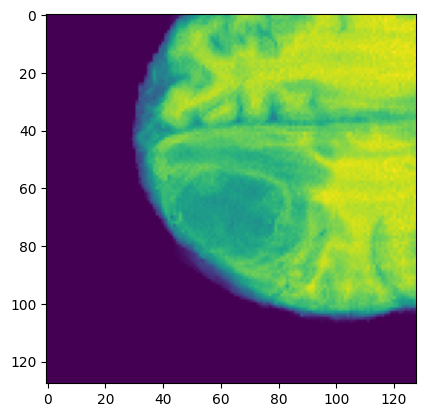

In [26]:
# Center-crop (with padding if needed)
t1_imgff    = center_crop_3d_with_padding_numpy_with_center(t1_img,center=center_TC)
import matplotlib.pyplot as plt
plt.imshow(t1_imgff[:,:,70])

In [16]:
t1_img    = nib.load(t1_path).get_fdata()
t1gd_img  = nib.load(t1gd_path).get_fdata()
t2_img    = nib.load(t2_path).get_fdata()
flair_img = nib.load(flair_path).get_fdata()
label_img = nib.load(label_path).get_fdata()


# Stack the modalities into one array to find the non-zero region (shape: [4, D, H, W])
patient_image = np.stack([t1_img, t1gd_img, t2_img, flair_img], axis=0)

# Identify the bounding box around non-zero voxels
mask = np.sum(patient_image, axis=0) != 0
z_idxs, y_idxs, x_idxs = np.nonzero(mask)

# Compute bounding box with a 1-voxel margin, ensuring indices don't go below 0
zmin = max(0, np.min(z_idxs) - 1)
zmax = np.max(z_idxs) + 1
ymin = max(0, np.min(y_idxs) - 1)
ymax = np.max(y_idxs) + 1
xmin = max(0, np.min(x_idxs) - 1)
xmax = np.max(x_idxs) + 1

# Crop each modality
t1_img    = t1_img[zmin:zmax, ymin:ymax, xmin:xmax]
t1gd_img  = t1gd_img[zmin:zmax, ymin:ymax, xmin:xmax]
t2_img    = t2_img[zmin:zmax, ymin:ymax, xmin:xmax]
flair_img = flair_img[zmin:zmax, ymin:ymax, xmin:xmax]
label_img = label_img[zmin:zmax, ymin:ymax, xmin:xmax]


# Center-crop (with padding if needed)
t1_img    = center_crop_3d_with_padding_numpy_with_center(t1_img,center=center_TC)
t1gd_img  = center_crop_3d_with_padding_numpy_with_center(t1gd_img,center=center_TC)
t2_img    = center_crop_3d_with_padding_numpy_with_center(t2_img,center=center_TC)
flair_img = center_crop_3d_with_padding_numpy_with_center(flair_img,center=center_TC)
label_img = center_crop_3d_with_padding_numpy_with_center(label_img,center=center_TC)
t1_data = t1_img 
t1gd_data = t1gd_img
t2_data = t2_img
flair_data = flair_img
label_data = label_img


pad ((0, 7), (18, 0), (0, 2))
pad ((0, 7), (18, 0), (0, 2))
pad ((0, 7), (18, 0), (0, 2))
pad ((0, 7), (18, 0), (0, 2))
pad ((0, 7), (18, 0), (0, 2))


# Sampling Contours

In [17]:
from utils.CT_sampling_support import (convert2diploar, extract_boundary,spherical_to_cartesian,
                                       r_max_region,fps,equally_sampling_spherical,calculate_centroid)
# Define parameters
n_regions_theta = 128  # Number of theta bins
n_regions_phi = 128    # Number of phi bins


theta_edges = np.linspace(0, 2*np.pi, n_regions_theta+1)  # 128 bins for theta
phi_edges = np.linspace(0,   np.pi, n_regions_phi+1)  # 128 bins for phi
center_TC = calculate_centroid(label_data)
coordinates = convert2diploar(label_data)


# Prepare bins for theta and phi

select_points_TC,select_points_WT,select_points_HT = extract_boundary(t1_data, label_data,coordinates,n_regions_phi, n_regions_theta)
r_stat_center = np.zeros(shape=(n_regions_theta,n_regions_phi))
r_stat_TC = r_max_region(select_points_TC)
r_stat_WT = r_max_region(select_points_WT)
r_stat_HT = r_max_region(select_points_HT)

# print('0: TC',select_points_TC.shape,'WT',select_points_WT.shape,'HT',select_points_HT.shape)
TC_points_xyz = spherical_to_cartesian(select_points_TC) 
WT_points_xyz = spherical_to_cartesian(select_points_WT)   
HT_points_xyz = spherical_to_cartesian(select_points_HT)   

TC_points_xyz = fps(TC_points_xyz,4096)
WT_points_xyz = fps(WT_points_xyz,4096)
HT_points_xyz = fps(HT_points_xyz,4096)
# print('1: TC',TC_points_xyz.shape,'WT',WT_points_xyz.shape,'HT',HT_points_xyz.shape)
rate = 0.005

all_TC_s = []
all_d_tcs = []
all_TC_l = []
all_d_tcl = []
all_WT_s = []
all_d_wts = []
all_WT_l = []
all_d_wtl = []


# Loop to run the function 4 times
for _ in range(1):

    TC_l, d_tcl = equally_sampling_spherical(TC_points_xyz, center_TC, r_stat_TC, r_stat_WT, rate, 300, theta_edges, phi_edges)
    WT_s, d_wts = equally_sampling_spherical(WT_points_xyz, center_TC, r_stat_TC, r_stat_WT, -rate, 300, theta_edges, phi_edges)
    all_TC_l.append(TC_l)
    all_d_tcl.append(d_tcl)
    all_WT_s.append(WT_s)
    all_d_wts.append(d_wts)

rate2 = 0.02
for _ in range(4):
    TC_s, d_tcs = equally_sampling_spherical(TC_points_xyz, center_TC, r_stat_center, r_stat_TC, -rate2, 50, theta_edges, phi_edges, withinTC=True)
    WT_l, d_wtl = equally_sampling_spherical(WT_points_xyz, center_TC, r_stat_WT, r_stat_HT, rate2, 50, theta_edges, phi_edges, outWT=True)
    # Append results to lists
    all_TC_s.append(TC_s)
    all_d_tcs.append(d_tcs)
    all_WT_l.append(WT_l)
    all_d_wtl.append(d_wtl)
    # Append results to lists


# Concatenate results

final_TC_s = np.concatenate(all_TC_s, axis=0)
final_d_tcs = np.concatenate(all_d_tcs, axis=0)
final_TC_l = np.concatenate(all_TC_l, axis=0)
final_d_tcl = np.concatenate(all_d_tcl, axis=0)
final_WT_s = np.concatenate(all_WT_s, axis=0)
final_d_wts = np.concatenate(all_d_wts, axis=0)
final_WT_l = np.concatenate(all_WT_l, axis=0)
final_d_wtl = np.concatenate(all_d_wtl, axis=0)


# Image embedding extraction

In [18]:
import torch
from models.CKD_model import CKD,CKD_encoder_only
img_encoder= CKD_encoder_only(embed_dim=32, output_dim=3, img_size=(128, 128, 128), patch_size=(4, 4, 4), in_chans=1, depths=[2, 2, 2], num_heads=[2, 4, 8, 16], window_size=(7, 7, 7), mlp_ratio=4.)
img_encoder.load_state_dict(torch.load("/Users/yifanli/Desktop/P3SOTA/CKD-TransBTS-main/best_model_BraTs.pkl", map_location='cpu'))
img_encoder.eval()
print()

/opt/anaconda3/lib/python3.8/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [19]:
patient_image =np.stack([
    t1_data,
    t1gd_data,
    t2_data ,
    flair_data
], axis=0, dtype=np.float32)


batch_tensor = torch.from_numpy(np.repeat(patient_image[None,:,:,:,:],2, axis=0))
with torch.no_grad():
    img_embeddings = img_encoder(batch_tensor)
print(img_embeddings.shape)

torch.Size([2, 1024, 4, 4, 4])


# PC embedding extraction

In [20]:
from models.Point_NN import Point_NN
device = torch.device("cpu")

PN_model = Point_NN(
    input_points=4096, 
    num_stages=4, 
    embed_dim=72, 
    k_neighbors=30, 
    beta=1000, 
    alpha=100
).to(device)

PN_model.eval()
print()

In [21]:
g_tc_s = torch.from_numpy(final_TC_s).permute(0,2,1).float()
g_tc_l = torch.from_numpy(final_TC_l).permute(0,2,1).float()
g_wt_l = torch.from_numpy(final_WT_l).permute(0,2,1).float()

with torch.no_grad():
    g_tc_s_embedding = PN_model(g_tc_s) 
    g_tc_l_embedding = PN_model(g_tc_l) 
    g_wt_l_embedding = PN_model(g_wt_l) 

In [22]:
print(g_tc_s.shape,g_tc_s_embedding.shape)
print(g_tc_l.shape,g_tc_l_embedding.shape)
print(g_wt_l.shape,g_wt_l_embedding.shape)

torch.Size([200, 3, 4096]) torch.Size([200, 1152])
torch.Size([300, 3, 4096]) torch.Size([300, 1152])
torch.Size([200, 3, 4096]) torch.Size([200, 1152])


# Run the Contrastive Model

In [23]:
from models.DCMModel import ContourEncoder
name = '25thFeb/CMrank_11_10_50.pth'
dic_pth = '/Users/yifanli/Desktop/fromLinux/TumorContour/'+ name
print('name',name)
CM_model = ContourEncoder(
    img_channels=1024,
    contour_dim=1152,
    hidden_dim=256,
    n_heads=4,
    num_decoder_layers=1
)
state_dict = torch.load(dic_pth, map_location=torch.device('cpu'))
CM_model.load_state_dict(state_dict, strict=False)
CM_model.eval()
print()

name 25thFeb/CMrank_11_10_50.pth



In [24]:
indices = np.concatenate([np.arange(i + 25, i + 50) for i in range(0, 200, 50)])
all_g_embs = torch.cat([g_tc_s_embedding.flip(0)[indices,:], g_tc_l_embedding, g_wt_l_embedding[indices,:]], dim=0)
image_emb = img_embeddings[0:1,:,:,:,:]
P_test = all_g_embs.size(0)
image_batch = image_emb.repeat(P_test, 1, 1, 1, 1)
with torch.no_grad():
    emb_g = CM_model(image_batch, all_g_embs)
n_tc = 100
n_inf=300
# Partition the embeddings
e_tc = emb_g[:n_tc]              # (n_tc, hidden_dim)
e_inf = emb_g[n_tc : n_tc+n_inf]   # (n_inf, hidden_dim)
e_ht = emb_g[n_tc+n_inf :]         # (remaining, hidden_dim)

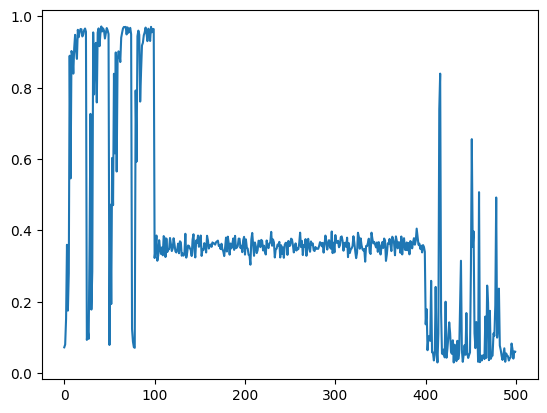

In [25]:
alpha = 5.0
e_tc_norm  = F.normalize(e_tc,  p=2, dim=-1)
e_inf_norm = F.normalize(e_inf, p=2, dim=-1)
e_ht_norm  = F.normalize(e_ht,  p=2, dim=-1)
sim_tc_mat = torch.matmul(emb_g, e_tc_norm.transpose(0,1))
sim_tc_avg = sim_tc_mat.mean(dim=1)

sim_ht_mat = torch.matmul(emb_g, e_ht_norm.transpose(0,1))
sim_ht_avg = sim_ht_mat.mean(dim=1)        
# (C) Softmax-like transform to probability.

num = torch.exp(alpha * sim_tc_avg)
den = num + torch.exp(alpha * sim_ht_avg)
p_tumor_cos = num / den
plt.plot(p_tumor_cos)

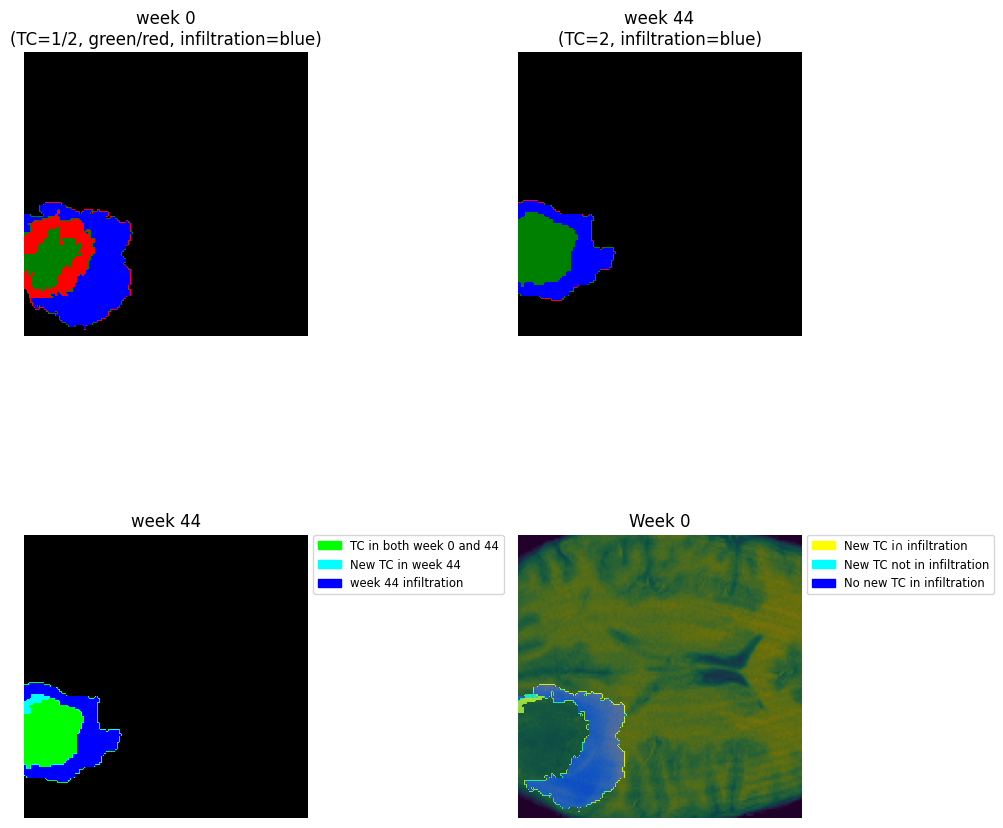

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

label_path2 = '/Users/yifanli/Desktop/registered_T2_mask_week044.nii.gz'
label_img2 = nib.load(label_path2).get_fdata()
label_img2 = label_img2[zmin:zmax, ymin:ymax, xmin:xmax]
label_img2 = center_crop_3d_with_padding_numpy(label_img2)

m1 = label_data
m2 =label_img2 
print(m1.shape,m2.shape)

slice_ = 70
# Shared color scheme for all labels (0-3)
shared_colors = ['black', 'red', 'green', 'blue']  # 0,1,2,3

# Create subplots with a larger figure size
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# --- Figure 1: m1 only ---
axes[0,0].imshow(m1[:, :, slice_], cmap=ListedColormap(shared_colors))
axes[0,0].set_title("week 0\n(TC=1/2, green/red, infiltration=blue)")
axes[0,0].axis('off')

# --- Figure 2: m2 only ---
axes[0,1].imshow(m2[:, :, slice_], cmap=ListedColormap(shared_colors))
axes[0,1].set_title("week 44\n(TC=2, infiltration=blue)")
axes[0,1].axis('off')

# --- Figure 3: Modified TC Comparison with m2 Label3 ---
m1_slice = m1[:, :, slice_]
m2_slice = m2[:, :, slice_]

# Create comparison matrix
tc_comparison = np.zeros_like(m1_slice)

# Categories:
# 0 = Background
# 1 = TC in both (m1:1/2 and m2:2)
# 2 = TC new in m2 (m2:2 not in m1 TC)
# 3 = m2 Label3
tc_comparison[np.isin(m1_slice, [1,2]) & (m2_slice == 2)] = 1  # Overlap
tc_comparison[(m2_slice == 2) & ~np.isin(m1_slice, [1,2])] = 2  # New TC
tc_comparison[m2_slice == 3] = 3  # m2 Label3

# Custom colormap
cmp_cmap = ListedColormap(['black', 'lime', 'cyan', 'blue'])
axes[1,0].imshow(tc_comparison, cmap=cmp_cmap, vmin=0, vmax=3)
axes[1,0].set_title("week 44")
axes[1,0].axis('off')

# --- Figure 4: Overlap of New TC and m1 Label3 ---
overlap_comparison = np.zeros_like(m1_slice)

# Create masks
new_tc_mask = (tc_comparison == 2)  # Cyan areas from Figure3
m1_label3_mask = (m1_slice == 3)    # Blue areas from Figure1

# Categories:
# 0 = Background
# 1 = New TC overlapping m1 Label3
# 2 = New TC only
# 3 = m1 Label3 only
overlap_comparison[new_tc_mask & m1_label3_mask] = 1
overlap_comparison[new_tc_mask & ~m1_label3_mask] = 2
overlap_comparison[~new_tc_mask & m1_label3_mask] = 3

# Custom colormap
overlap_cmap = ListedColormap(['black', 'yellow', 'cyan', 'blue'])

axes[1,1].imshow(overlap_comparison, cmap=overlap_cmap, vmin=0, vmax=3)
axes[1,1].imshow(t1_img[:, :, slice_],alpha=0.5)
axes[1,1].set_title(
    "Week 0"
)
axes[1,1].axis('off')

# Add legends
legend_f3 = [
    mpatches.Patch(color='lime', label='TC in both week 0 and 44'),
    mpatches.Patch(color='cyan', label='New TC in week 44'),
    mpatches.Patch(color='blue', label='week 44 infiltration')
]
leg3 = axes[1,0].legend(
    handles=legend_f3, 
    bbox_to_anchor=(1.02, 1),   # shift legend to the right
    loc='upper left', 
    borderaxespad=0.,
    fontsize='small'            # you can adjust text size here
)

legend_f4 = [
    mpatches.Patch(color='yellow', label='New TC i∩ infiltration'),
    mpatches.Patch(color='cyan', label='New TC not in infiltration'),
    mpatches.Patch(color='blue', label='No new TC in infiltration')
]
leg4 = axes[1,1].legend(
    handles=legend_f4, 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0.,
    fontsize='small'
)

# Adjust layout so subplots and legends fit well
plt.tight_layout()

plt.show()


In [ ]:
# Create comparison matrix
tc_comparison = np.zeros_like(m1)

# Categories:
# 0 = Background
# 1 = TC in both (m1:1/2 and m2:2)
# 2 = TC new in m2 (m2:2 not in m1 TC)
# 3 = m2 Label3
tc_comparison[np.isin(m1, [1,2]) & (m2 == 2)] = 1  # Overlap
tc_comparison[(m2 == 2) & ~np.isin(m1, [1,2])] = 2  # New TC
tc_comparison[m2 == 3] = 3  # m2 Label3



# --- Figure 4: Overlap of New TC and m1 Label3 ---
overlap_comparison = np.zeros_like(m1)

# Create masks
new_tc_mask = (tc_comparison == 2)  # Cyan areas from Figure3
m1_label3_mask = (m1 == 3)    # Blue areas from Figure1

# Categories:
# 0 = Background
# 1 = New TC overlapping m1 Label3
# 2 = New TC only
# 3 = m1 Label3 only
overlap_comparison[new_tc_mask & m1_label3_mask] = 1
overlap_comparison[new_tc_mask & ~m1_label3_mask] = 2
overlap_comparison[~new_tc_mask & m1_label3_mask] = 3
